## **Lorenz 96 Model Learned by SREINet**


## **I. Setup and Preprocessing**

In [37]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

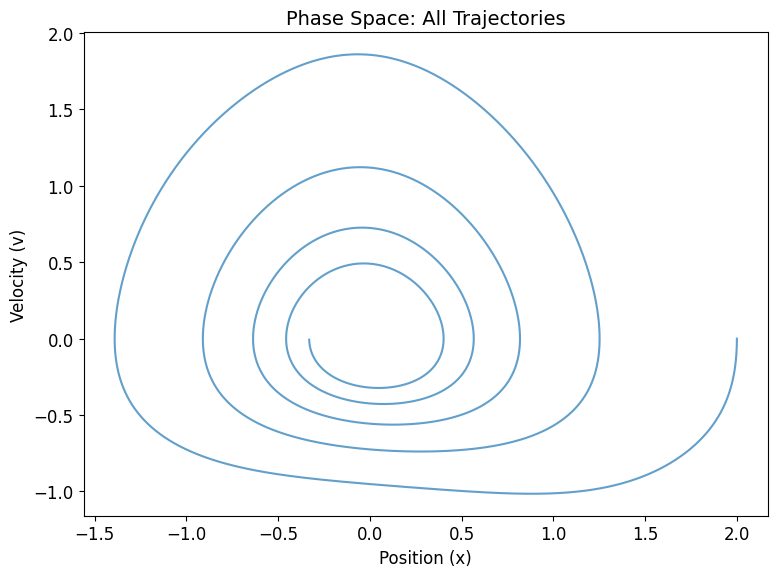

Training input shape: (6000, 2)
Training output shape: (6000, 2)


In [38]:
import matplotlib.pyplot as plt

def odefun(t, y):
    x, v = y
    dxdt = v 
    dvdt = -x - 0.1*v - np.sin(x * v)
    return [dxdt, dvdt]

# Generate multiple initial conditions (same as before)
t_span = (0, 30)                      # time interval
num_trajectories = 5                 # number of different trajectories
dt = 0.005                            # time step

# Generate multiple initial conditions
initial_conditions = [(2.0, 0)]

# Initialize DataGenerator with correct parameters
myDG = DG.DataGenerator(
    initial_conditions=initial_conditions,  # multiple initial conditions
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

# FIXED: Generate trajectories manually (avoiding the bug in generate_dataset_by_custom_ODEs)
x_train_list = []
dx_train_list = []

for ic in initial_conditions:
    # Generate trajectory for each initial condition
    temp_x, temp_dx = myDG.generate_ode_traj_with_ic(odefun, ic, myDG.derivative_mode)
    x_train_list.append(temp_x)
    dx_train_list.append(temp_dx)

# Combine all trajectories
x_train = np.vstack(x_train_list)
dx_train = np.vstack(dx_train_list)
t_arr = np.arange(myDG.t0, myDG.T, myDG.dt)

# Visualize the trajectories - Phase space plot only
plt.figure(figsize=(8, 6))

plt.title('Phase Space: All Trajectories', fontsize=14)
plt.xlabel('Position (x)', fontsize=12)
plt.ylabel('Velocity (v)', fontsize=12)

# Plot each trajectory with different colors
time_points_per_traj = len(t_arr)
colors = plt.cm.tab10(np.linspace(0, 1, len(initial_conditions)))

for i in range(len(initial_conditions)):
    start_idx = i * time_points_per_traj
    end_idx = (i + 1) * time_points_per_traj
    traj_x = x_train[start_idx:end_idx, 0]
    traj_v = x_train[start_idx:end_idx, 1]
    plt.plot(traj_x, traj_v, color=colors[i], alpha=0.7, linewidth=1.5,
             label=f'Traj {i+1}' if i < 5 else "")

plt.tight_layout()
plt.show()

# Prepare data for training
training_input, training_output = x_train, dx_train 
training_input_for_sim = training_input.copy() # Save copy for simulation

# Shuffle data (mixing all trajectories)
training_input, training_output = myDG.shuffleData(training_input, training_output)

print(f"Training input shape: {training_input.shape}")
print(f"Training output shape: {training_output.shape}")

### **1.3 Hyperparameters**


In [39]:
# Set mini-batch size
MINI_BATCH_SIZE = 32
learning_rate = 0.001

### **1.4 Model Architecture Definitions**


**SREINet Parameters**

In [40]:
# Assign dim to be the 2nd dimension of the training data (number of input variables)
dim = training_input.shape[1] 

guess_highest_order_polynomial = 6 # depth of SREINet

layer_depth = guess_highest_order_polynomial

# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * layer_depth

## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [41]:
my_activation = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn,
                     activations=my_activation,
                     weight_initializer=tf.initializers.random_normal(stddev=0.1, seed=42),
                     data_type=MY_DATA_TYPE,
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            tf.random.set_seed(42) 
            model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")

### **2.2 Loss Function**

In [42]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [43]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [44]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **Pruning Profile**

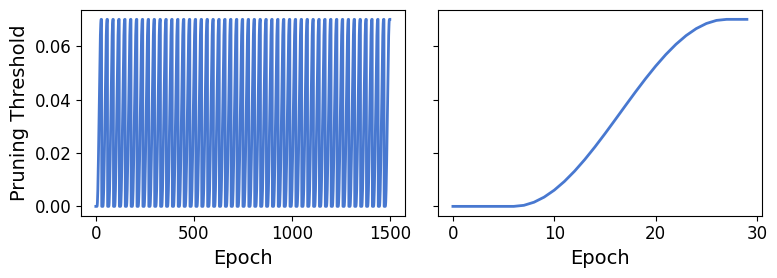

In [45]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.07 #Threshold for 10D Lorenz 96 model. Uses linear prune schedule
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 30
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    #ramp_type='sigmoid',
                    show_plot=True)

### Training

In [46]:
#Setup

EARLY_STOPPING_LOSS_THRESHOLD = 1e-7   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.02


training_histories = []
weights_list = []
loss_list = []

In [47]:
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     shuffle_per_epoch=False,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)   

Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 3.716e-01,  Validation Loss: 3.205e-01,  Epoch Time: 0.63s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 2.528e-01,  Validation Loss: 2.220e-01,  Epoch Time: 0.15s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 2.028e-01,  Validation Loss: 1.904e-01,  Epoch Time: 0.13s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 1.687e-01,  Validation Loss: 1.474e-01,  Epoch Time: 0.12s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 1.359e-01,  Validation Loss: 1.268e-01,  Epoch Time: 0.12s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 1.223e-01,  Validation Loss: 1.171e-01,  Epoch Time: 0.16s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 1.182e-01,  Validation Loss: 1.174e-01,  Epoch Time: 0.12s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 1.138e-01,  Validation Loss: 1.140e-01,  Epoch Time: 0.12s,  Curre

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [53]:
def generate_set_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)] + [f'cos(x{i})' for i in range(1, N+1)] + [f'sin(x{i})' for i in range(1, N+1)]

def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [54]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_set_labels, generate_LHS_labels)

## **V. Results**
### **Identified Model**

In [56]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 5e-2,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 0.9998578103*x2
(x2)' =  - 1.000067312*x1 - 0.1000032522*x2 - 1.001722835*x1*x2 + 0.1512247098*x1^3*x2^3


### **Validation**

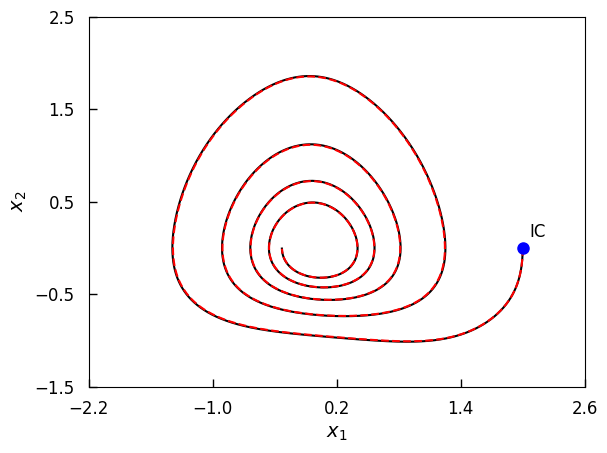

In [58]:
def identifed_ode(t, x):
    x1, x2 = x
    dx1dt = 0.9998874792*x2 
    dx2dt = - 0.9998330635*x1 - 0.09993111844*x2 - 1.000106383*x1*x2 + 0.1512247098*x1**3*x2**3# copy from the identified model, replace ^ by **
    return [dx1dt, dx2dt]

#validation using training initial conditions
y0 = initial_conditions[0]
val_DG = DG.DataGenerator(
    initial_conditions=[y0],         # list of ICs
    T=t_span[1],                     # end time
    dt=dt,                           # time step
    t0=t_span[0],                    # start time
    noise_level=0.0,                 # no noise for now
    random_state=42                  # for reproducibility
)

val_x, val_dx = val_DG.generate_ode_traj_with_ic(identifed_ode, y0)

true_x, true_y = myDG.generate_ode_traj_with_ic(odefun, y0)

plt.plot(true_x[:,0], true_x[:,1], label='True',color='black')

plt.plot(val_x[:,0], val_x[:,1], label='Identified',color='red',linestyle='--')
plt.plot(true_x[0,0], true_x[0,1], 'bo', markersize=8)

plt.annotate('IC', (true_x[0,0], true_x[0,1]), 
             xytext=(5, 8), textcoords='offset points',
             fontsize=12, ha='left')

plt.xlim([-2.2,2.6])
plt.xticks([-2.2, -1.0, 0.2, 1.4, 2.6])
plt.ylim([-1.5,2.5])
plt.yticks([-1.5, -0.5, 0.5, 1.5, 2.5])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.tick_params(direction='in', length=6, width=1)
plt.tick_params(axis='y', pad=10)
plt.tick_params(axis='x', pad=10)

plt.show()

In [59]:
# Output validation results to numpy file
np.savez_compressed('sin(xy)_nonlinearity_large_IC.npz',
                    val_x=val_x, 
                    val_dx=val_dx,
                    true_x=true_x,
                    true_y=true_y)
print("Results saved to 'sin(xy)_nonlinearity_large_IC.npz'")

Results saved to 'sin(xy)_nonlinearity_large_IC.npz'
